# Eval Trace Analyzer
Анализ результатов `eval_game.py` — длины промпта, ответов, thinking, обрезания, время.

In [67]:
import json, re, pathlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

plt.rcParams.update({
    'figure.dpi': 130,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
})

In [ ]:
# ── Загрузка файлов ───────────────────────────────────────────────────────────
RESULTS_DIR = pathlib.Path('results')

files = sorted(RESULTS_DIR.glob('eval_trace_*.json'))
print(f'Найдено файлов: {len(files)}')
for f in files:
    print(f'  {f.name}')

# Выбираем последний; можно заменить на конкретный путь
TRACE_FILE = files[4]
print(f'\nАнализируем: {TRACE_FILE.name}')

Найдено файлов: 7
  eval_trace_1779275077.json
  eval_trace_1779277721.json
  eval_trace_1779280591.json
  eval_trace_1779281436.json
  eval_trace_alexander_off.json
  eval_trace_config_full_think_on.json
  eval_trace_makononov_off_think_off.json

Анализируем: eval_trace_makononov_off_think_off.json


In [69]:
# ── Парсинг ───────────────────────────────────────────────────────────────────
_THINK_RE = re.compile(r'<think>(.*?)</think>', re.DOTALL)

_CALL_COLS = [
    'move_index', 'move_san', 'call_num', 'is_retry', 'elapsed_s',
    'max_tokens', 'finish_reason', 'prompt_chars', 'raw_chars',
    'think_chars', 'stripped_chars', 'is_think_only', 'truncated',
]

def extract_think_chars(raw: str) -> int:
    m = _THINK_RE.search(raw)
    return len(m.group(0)) if m else 0

def section_chars(sections: list[dict]) -> dict[str, int]:
    """Длина каждого раздела промпта по label."""
    return {s['label']: len(s.get('content', '')) for s in sections}

def parse_trace(path: pathlib.Path):
    data = json.loads(path.read_text())
    meta = {
        'game':           data.get('game', {}),
        'config':         data.get('config'),
        'run_config':     data.get('run_config', {}),
        'run_config_file':data.get('run_config_file'),
        'max_tokens':     data.get('max_tokens'),
        'analysis_depth': data.get('analysis_depth'),
        'fixture':        data.get('fixture'),
    }

    move_rows, call_rows, section_rows = [], [], []

    for t in data['traces']:
        if t.get('san') is None:
            continue

        calls     = t.get('lm_calls', [])
        n_calls   = len(calls)
        total_el  = sum(c.get('elapsed_s', 0) for c in calls)
        trunc_raw = any(c.get('finish_reason') == 'length' for c in calls)

        def _stripped_truncated(c):
            if c.get('finish_reason') != 'length':
                return False
            think = extract_think_chars(c.get('raw_response', ''))
            raw   = c.get('response_chars', 0)
            return (raw - think) >= raw * 0.5

        trunc_stripped = any(_stripped_truncated(c) for c in calls)

        # per-section prompt lengths
        sec = section_chars(t.get('prompt_sections', []))
        for label, chars in sec.items():
            section_rows.append({
                'move_index': t['index'],
                'san':        t.get('san'),
                'label':      label,
                'chars':      chars,
            })

        move_rows.append({
            'index':              t['index'],
            'move_number':        t.get('move_number'),
            'san':                t.get('san'),
            'color':              t.get('color'),
            'quality':            t.get('quality'),
            'question_type':      t.get('question_type'),
            'eval_cp':            t.get('eval_cp'),
            'eval_loss_cp':       t.get('eval_loss_cp'),
            'prompt_chars':       t.get('prompt_chars', 0),
            'prompt_tokens':      t.get('prompt_tokens_est', 0),
            'commentary_chars':   t.get('commentary_chars', 0),
            'commentary_empty':   t.get('commentary_empty', False),
            'retried':            t.get('retried', False),
            'n_calls':            n_calls,
            'total_elapsed_s':    total_el,
            'truncated_raw':      trunc_raw,
            'truncated_stripped': trunc_stripped,
        })

        for ci, c in enumerate(calls):
            raw       = c.get('raw_response', '')
            think_ch  = extract_think_chars(raw)
            raw_ch    = c.get('response_chars', len(raw))
            strip_ch  = c.get('stripped_chars', 0)
            call_rows.append({
                'move_index':    t['index'],
                'move_san':      t.get('san'),
                'call_num':      ci,
                'is_retry':      ci > 0,
                'elapsed_s':     c.get('elapsed_s', 0),
                'max_tokens':    c.get('max_tokens'),
                'finish_reason': c.get('finish_reason'),
                'prompt_chars':  c.get('prompt_chars', 0),
                'raw_chars':     raw_ch,
                'think_chars':   think_ch,
                'stripped_chars':strip_ch,
                'is_think_only': c.get('is_think_only', False),
                'truncated':     c.get('finish_reason') == 'length',
            })

    moves    = pd.DataFrame(move_rows)
    calls_df = pd.DataFrame(call_rows, columns=_CALL_COLS) if call_rows else pd.DataFrame(columns=_CALL_COLS)
    secs_df  = pd.DataFrame(section_rows)
    return meta, moves, calls_df, secs_df


meta, moves, calls, secs = parse_trace(TRACE_FILE)
g = meta['game']
print(f"Партия  : {g.get('White')} vs {g.get('Black')} ({g.get('Date')})")
print(f"Конфиг  : {meta['config']}  |  max_tokens={meta['max_tokens']}")
if meta.get('run_config_file'):
    print(f"JSON cfg: {pathlib.Path(meta['run_config_file']).name}")
print(f"Ходов   : {len(moves)}  |  LLM-вызовов: {len(calls)}")

Партия  : DzaWardo vs alfaomar2000 (2026.05.20)
Конфиг  : full+overrides={'include_makogonov': False}  |  max_tokens=350
JSON cfg: eval_config.json
Ходов   : 52  |  LLM-вызовов: 52


In [70]:
# ── Сводная таблица ───────────────────────────────────────────────────────────
first_calls = calls[calls['call_num'] == 0]

summary = {
    'Всего ходов':                          len(moves),
    'Всего LLM-вызовов':                    len(calls),
    'Ретраев':                              int(calls['is_retry'].sum()),
    'Пустых ответов':                       int(moves['commentary_empty'].sum()),
    'Think-only вызовов':                   int(calls['is_think_only'].sum()),

    'Ср. длина промпта, симв':              round(first_calls['prompt_chars'].mean(), 1),
    'Медиана длины промпта, симв':          round(first_calls['prompt_chars'].median(), 1),
    'Макс. длина промпта, симв':            int(first_calls['prompt_chars'].max()),

    'Ср. длина ответа (stripped), симв':    round(first_calls['stripped_chars'].mean(), 1),
    'Ср. длина thinking, симв':             round(first_calls['think_chars'].mean(), 1),
    'Ср. длина raw (с thinking), симв':     round(first_calls['raw_chars'].mean(), 1),

    'Обрезано (с учётом thinking)':         int(calls['truncated'].sum()),
    'Обрезан ответ (без thinking)':         int(sum(
        1 for _, r in calls.iterrows()
        if r['truncated'] and r['stripped_chars'] > r['think_chars'] * 0.5
    )),

    'Ср. время ответа, с':                  round(first_calls['elapsed_s'].mean(), 2),
    'Медиана времени, с':                   round(first_calls['elapsed_s'].median(), 2),
    'Макс. время, с':                       round(first_calls['elapsed_s'].max(), 2),
}

pd.DataFrame(summary.items(), columns=['Метрика', 'Значение'])

,Метрика,Значение
0,Всего ходов,52.00
1,Всего LLM-вызовов,52.00
2,Ретраев,0.00
3,Пустых ответов,0.00
4,Think-only вызовов,0.00
5,"Ср. длина промпта, симв",679.50
6,"Медиана длины промпта, симв",657.50
7,"Макс. длина промпта, симв",988.00
8,"Ср. длина ответа (stripped), симв",376.40
9,"Ср. длина thinking, симв",17.00


## Длина промпта

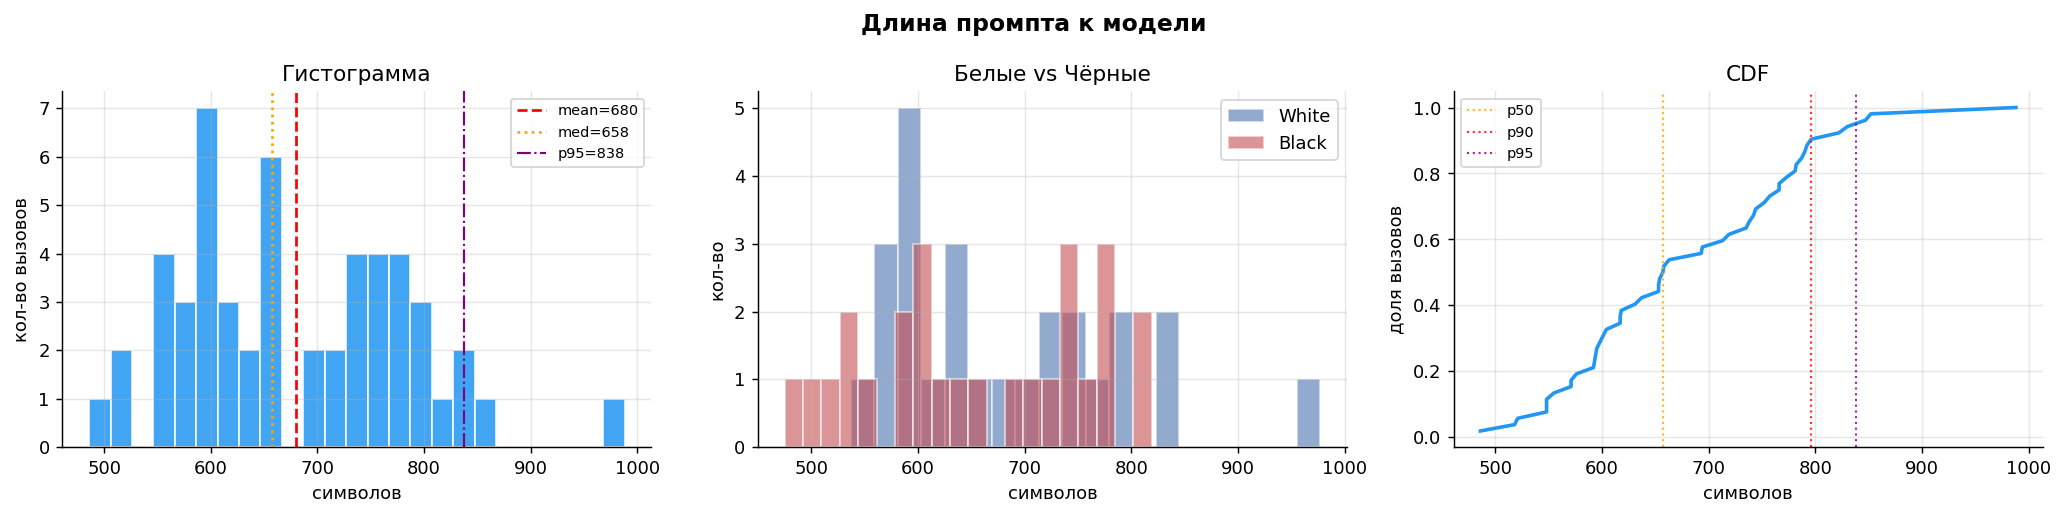

In [71]:
# ── Распределение длины промпта ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Длина промпта к модели', fontsize=13, fontweight='bold')

pc = first_calls['prompt_chars'].dropna()

# Гистограмма
ax = axes[0]
ax.hist(pc, bins=25, color='#2196F3', alpha=0.85, edgecolor='white')
ax.axvline(pc.mean(),            color='red',    linestyle='--', lw=1.5, label=f'mean={pc.mean():.0f}')
ax.axvline(pc.median(),          color='orange', linestyle=':',  lw=1.5, label=f'med={pc.median():.0f}')
ax.axvline(pc.quantile(0.95),    color='purple', linestyle='-.', lw=1.2, label=f'p95={pc.quantile(0.95):.0f}')
ax.set_title('Гистограмма')
ax.set_xlabel('символов')
ax.set_ylabel('кол-во вызовов')
ax.legend(fontsize=8)

# По цвету хода
ax = axes[1]
for color, hue in [('white', '#4C72B0'), ('black', '#C44E52')]:
    subset = moves.loc[moves['color'] == color, 'prompt_chars'].dropna()
    ax.hist(subset, bins=20, alpha=0.6, color=hue, edgecolor='white', label=color.capitalize())
ax.set_title('Белые vs Чёрные')
ax.set_xlabel('символов')
ax.set_ylabel('кол-во')
ax.legend()

# Cumulative
ax = axes[2]
sorted_pc = np.sort(pc)
cdf = np.arange(1, len(sorted_pc) + 1) / len(sorted_pc)
ax.plot(sorted_pc, cdf, color='#2196F3', lw=2)
ax.axvline(pc.quantile(0.5),  color='orange', linestyle=':', lw=1.2, alpha=0.8, label='p50')
ax.axvline(pc.quantile(0.9),  color='red',    linestyle=':', lw=1.2, alpha=0.8, label='p90')
ax.axvline(pc.quantile(0.95), color='purple', linestyle=':', lw=1.2, alpha=0.8, label='p95')
ax.set_title('CDF')
ax.set_xlabel('символов')
ax.set_ylabel('доля вызовов')
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

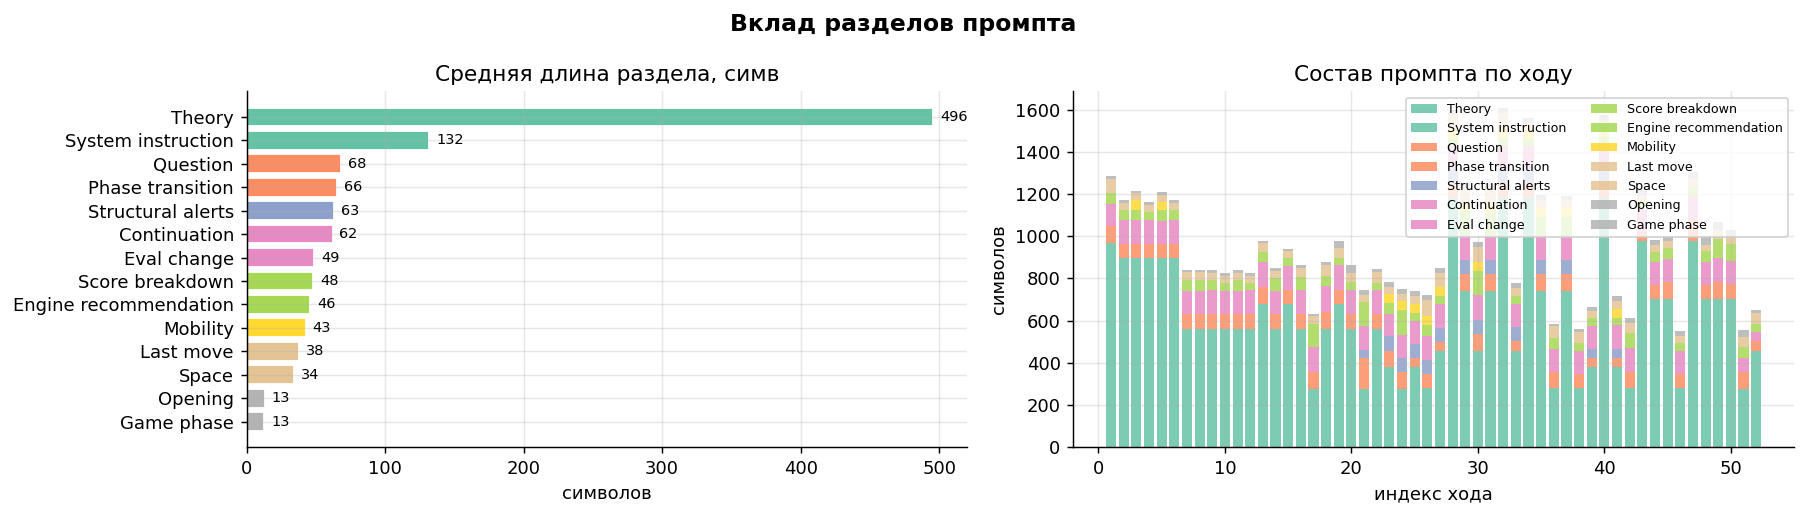

,Раздел,Ср. симв,Доля от промпта
0,Theory,495.6,74.1
1,System instruction,132.0,19.7
2,Question,68.3,10.2
3,Phase transition,65.5,9.8
4,Structural alerts,63.0,9.4
5,Continuation,62.0,9.3
6,Eval change,48.9,7.3
7,Score breakdown,48.0,7.2
8,Engine recommendation,46.0,6.9
9,Mobility,42.6,6.4


In [72]:
# ── Вклад каждого раздела в длину промпта ────────────────────────────────────
if not secs.empty:
    # Среднее по всем ходам
    sec_mean = secs.groupby('label')['chars'].mean().sort_values(ascending=False)
    sec_total = secs.groupby('label')['chars'].sum().sort_values(ascending=False)

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    fig.suptitle('Вклад разделов промпта', fontsize=13, fontweight='bold')

    colors = plt.cm.Set2(np.linspace(0, 1, len(sec_mean)))

    # Средние значения
    ax = axes[0]
    bars = ax.barh(sec_mean.index[::-1], sec_mean.values[::-1], color=colors[::-1], edgecolor='white')
    for bar, val in zip(bars, sec_mean.values[::-1]):
        ax.text(val + 5, bar.get_y() + bar.get_height()/2, f'{val:.0f}', va='center', fontsize=8)
    ax.set_title('Средняя длина раздела, симв')
    ax.set_xlabel('символов')

    # Stacked bar — состав промпта одного хода
    ax = axes[1]
    pivot = secs.pivot_table(index='move_index', columns='label', values='chars', fill_value=0)
    bottom = np.zeros(len(pivot))
    col_colors = dict(zip(sec_mean.index, plt.cm.Set2(np.linspace(0, 1, len(sec_mean)))))
    for label in sec_mean.index:
        if label in pivot.columns:
            vals = pivot[label].values
            ax.bar(pivot.index, vals, bottom=bottom, label=label,
                   color=col_colors[label], alpha=0.85, edgecolor='none')
            bottom += vals
    ax.set_title('Состав промпта по ходу')
    ax.set_xlabel('индекс хода')
    ax.set_ylabel('символов')
    ax.legend(fontsize=7, loc='upper right', ncol=2)

    plt.tight_layout()
    plt.show()

    # Таблица вкладов
    df_sec = pd.DataFrame({
        'Раздел':       sec_mean.index,
        'Ср. симв':     sec_mean.values.round(1),
        'Доля от промпта': (sec_mean / moves['prompt_chars'].mean() * 100).round(1),
    }).reset_index(drop=True)
    display(df_sec)
else:
    print('Данные по разделам промпта отсутствуют (старый формат трейса).')

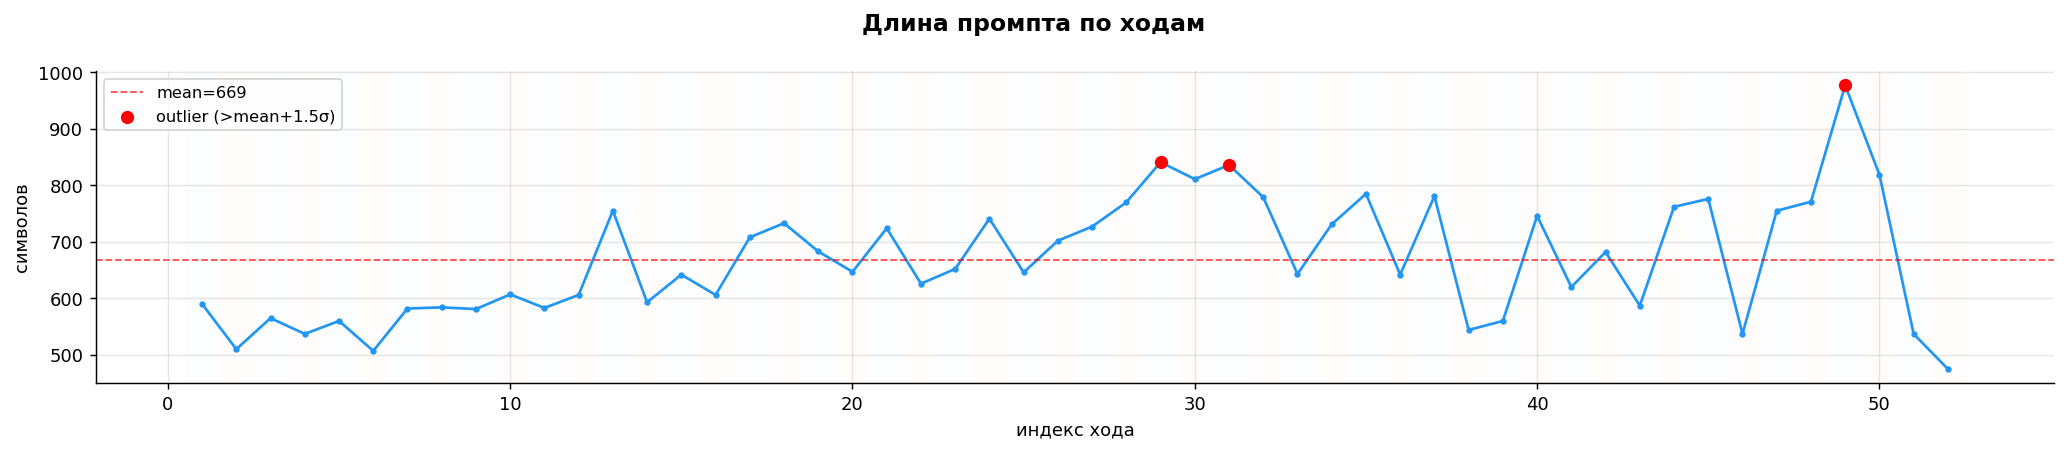

In [73]:
# ── Промпт по ходам: динамика ─────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 3.5))
fig.suptitle('Длина промпта по ходам', fontsize=13, fontweight='bold')

# Подложка белые/чёрные
for _, row in moves.iterrows():
    c = '#f0f8ff' if row['color'] == 'white' else '#fff5f0'
    ax.axvspan(row['index'] - 0.5, row['index'] + 0.5, alpha=0.25, color=c, linewidth=0)

ax.plot(moves['index'], moves['prompt_chars'], color='#2196F3', lw=1.5, marker='o', markersize=2.5)
ax.axhline(moves['prompt_chars'].mean(), color='red', linestyle='--', lw=1, alpha=0.7,
           label=f"mean={moves['prompt_chars'].mean():.0f}")

# Отметить ходы, где промпт резко вырос
threshold = moves['prompt_chars'].mean() + 1.5 * moves['prompt_chars'].std()
outliers = moves[moves['prompt_chars'] > threshold]
ax.scatter(outliers['index'], outliers['prompt_chars'],
           color='red', s=40, zorder=5, label='outlier (>mean+1.5σ)')

ax.set_xlabel('индекс хода')
ax.set_ylabel('символов')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## Длина ответа, thinking, время

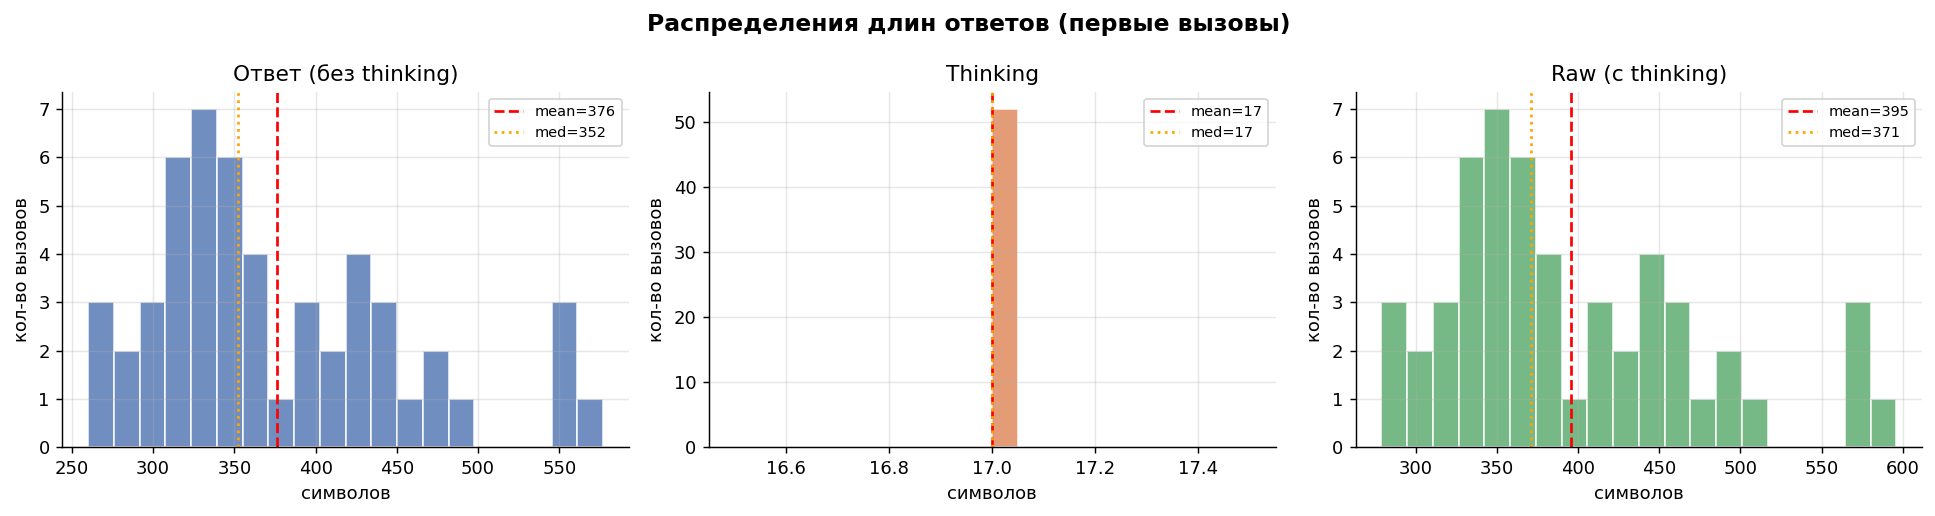

In [74]:
# ── Распределения длин ответа ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Распределения длин ответов (первые вызовы)', fontsize=13, fontweight='bold')

for ax, (col, label, color) in zip(axes, [
    ('stripped_chars', 'Ответ (без thinking)', '#4C72B0'),
    ('think_chars',    'Thinking',             '#DD8452'),
    ('raw_chars',      'Raw (с thinking)',      '#55A868'),
]):
    data = first_calls[col].dropna()
    ax.hist(data, bins=20, color=color, alpha=0.8, edgecolor='white')
    ax.axvline(data.mean(),   color='red',    linestyle='--', lw=1.5, label=f'mean={data.mean():.0f}')
    ax.axvline(data.median(), color='orange', linestyle=':',  lw=1.5, label=f'med={data.median():.0f}')
    ax.set_title(label)
    ax.set_xlabel('символов')
    ax.set_ylabel('кол-во вызовов')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

/var/folders/v7/jd9nwf555hqg15pmncp612mc0000gn/T/ipykernel_81454/1257441613.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax2.boxplot(groups, labels=['Первый вызов', 'Ретрай'], patch_artist=True,


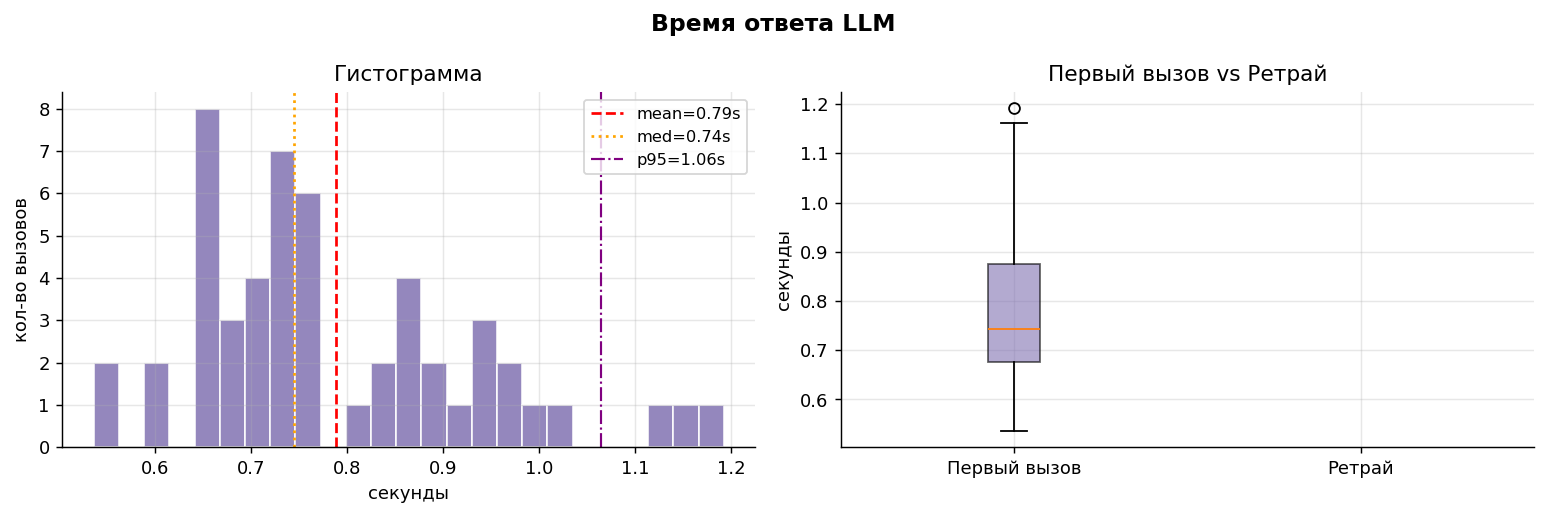

In [75]:
# ── Время ответа ──────────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Время ответа LLM', fontsize=13, fontweight='bold')

elapsed = first_calls['elapsed_s'].dropna()
ax1.hist(elapsed, bins=25, color='#8172B2', alpha=0.85, edgecolor='white')
ax1.axvline(elapsed.mean(),           color='red',    linestyle='--', lw=1.5, label=f'mean={elapsed.mean():.2f}s')
ax1.axvline(elapsed.median(),         color='orange', linestyle=':',  lw=1.5, label=f'med={elapsed.median():.2f}s')
ax1.axvline(elapsed.quantile(0.95),   color='purple', linestyle='-.', lw=1.2, label=f'p95={elapsed.quantile(0.95):.2f}s')
ax1.set_title('Гистограмма')
ax1.set_xlabel('секунды')
ax1.set_ylabel('кол-во вызовов')
ax1.legend(fontsize=9)

groups = [first_calls.loc[first_calls['is_retry'] == v, 'elapsed_s'].dropna() for v in [False, True]]
ax2.boxplot(groups, labels=['Первый вызов', 'Ретрай'], patch_artist=True,
            boxprops=dict(facecolor='#8172B2', alpha=0.6))
ax2.set_title('Первый вызов vs Ретрай')
ax2.set_ylabel('секунды')

plt.tight_layout()
plt.show()

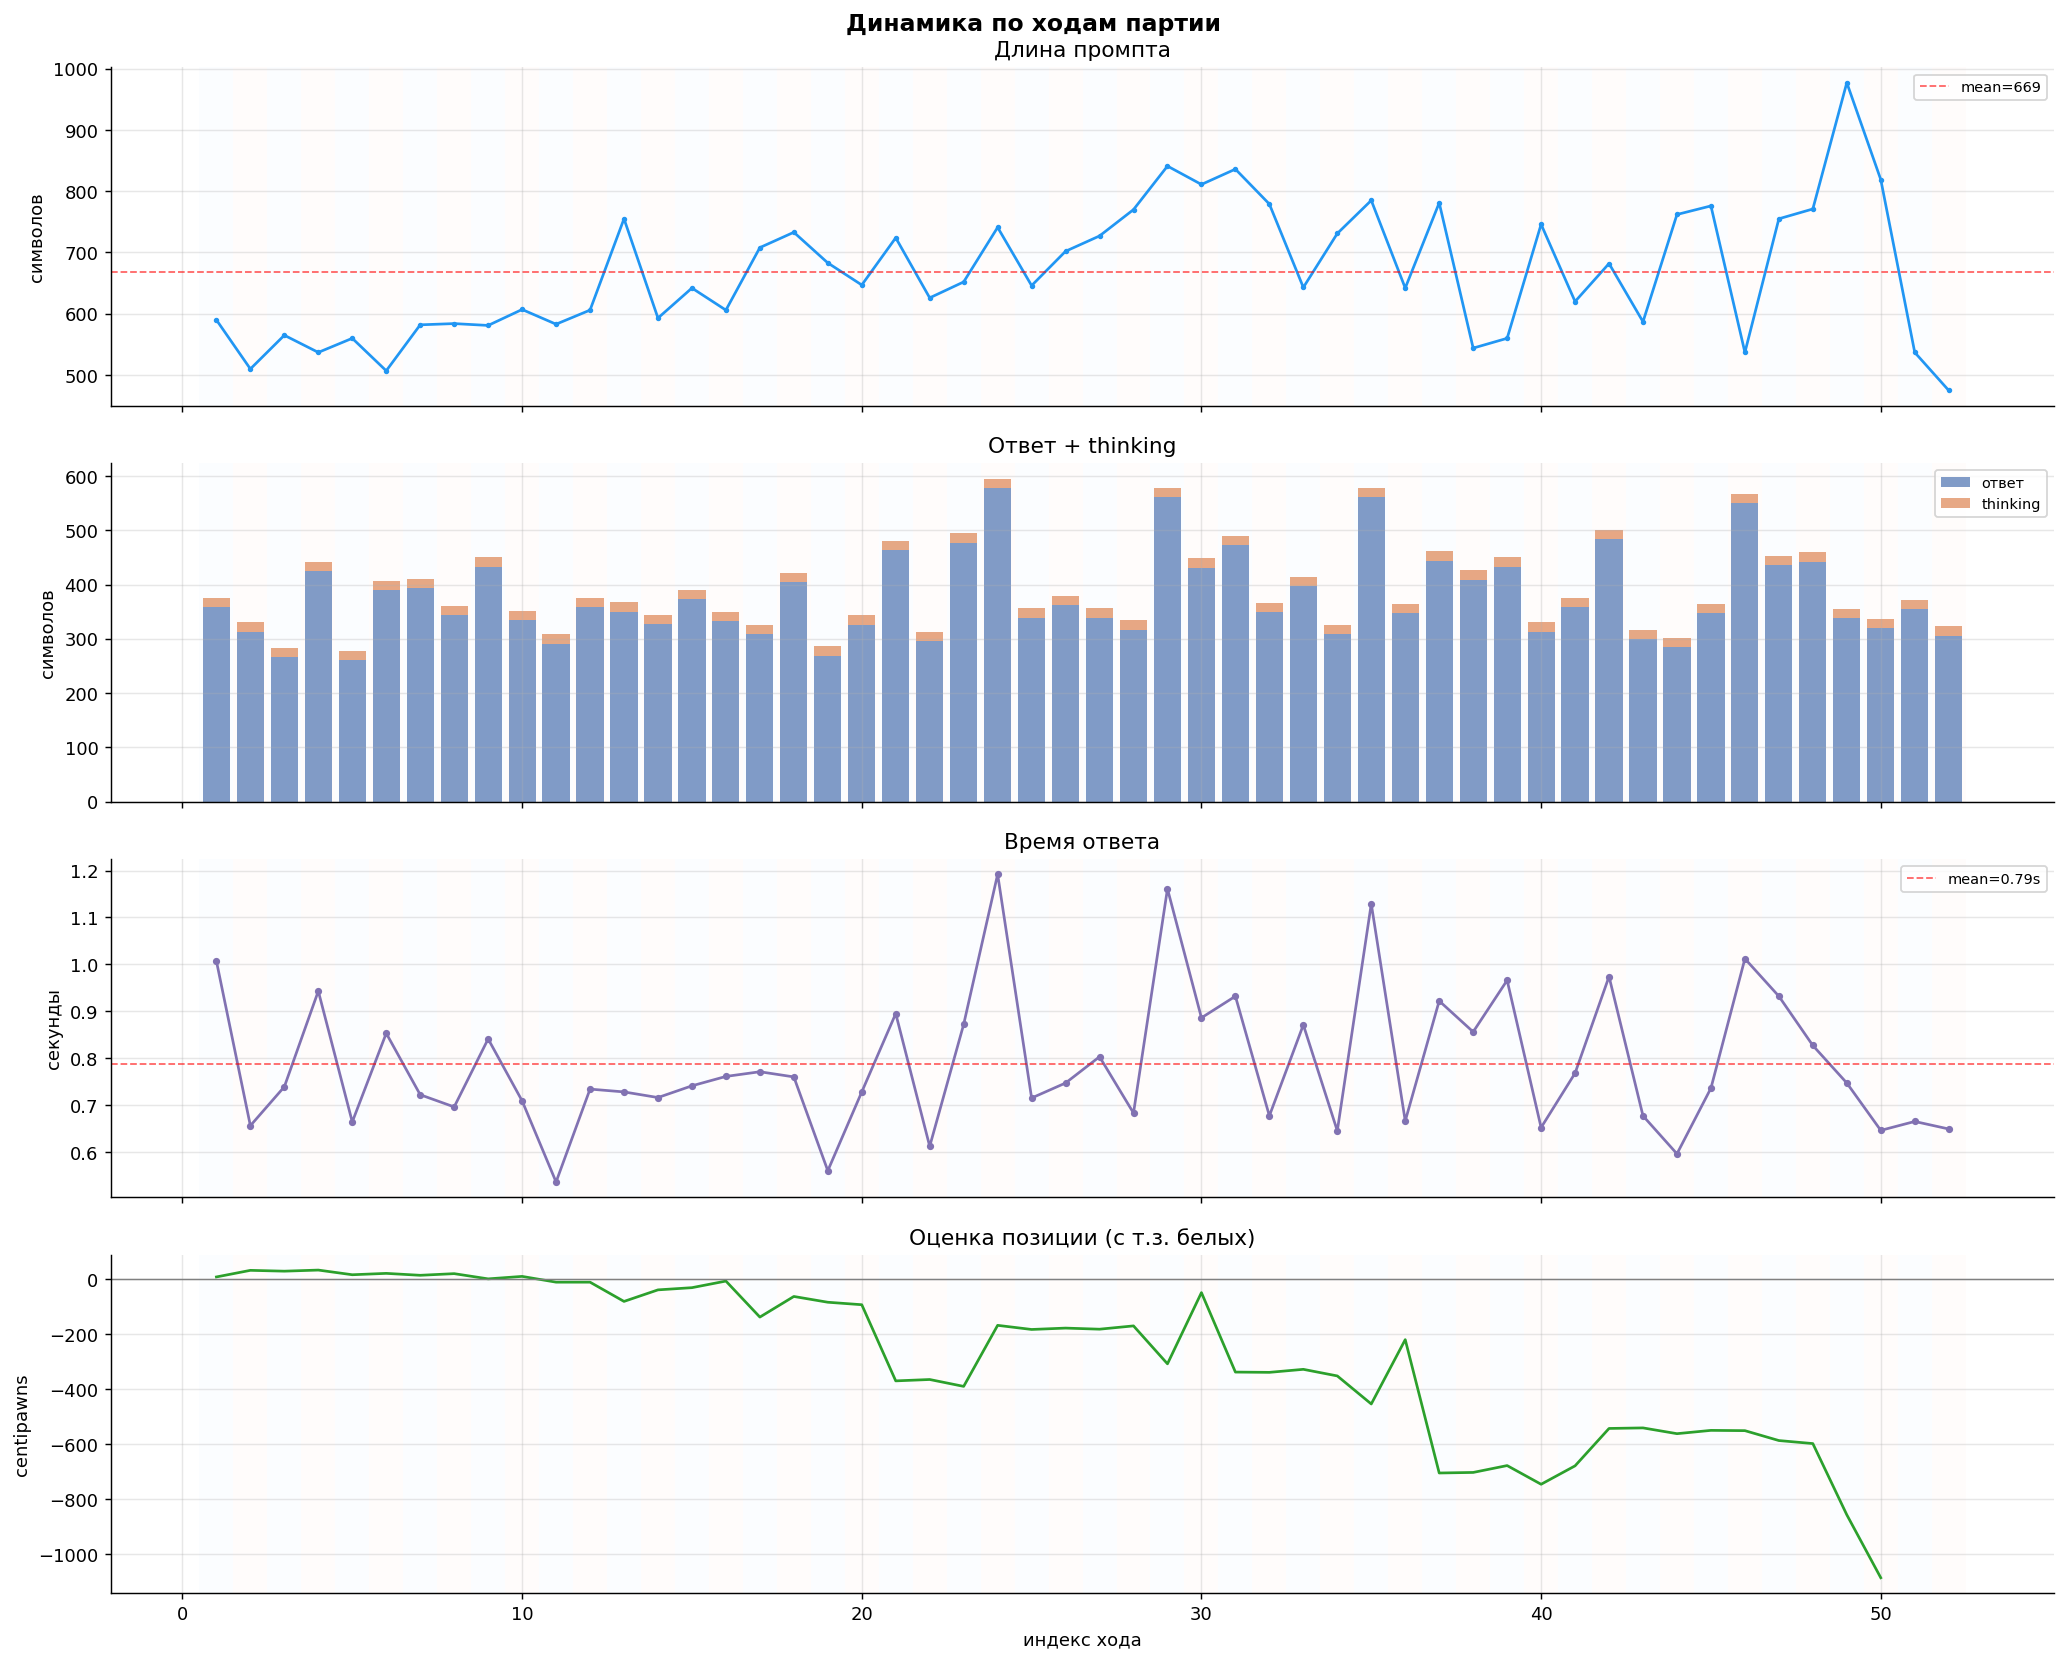

In [76]:
# ── Динамика по ходам ─────────────────────────────────────────────────────────
fc = first_calls[['move_index', 'stripped_chars', 'think_chars', 'raw_chars', 'elapsed_s', 'truncated']].copy()
fc = fc.rename(columns={'move_index': 'index'})
mfc = moves.merge(fc, on='index', how='left')

fig, axes = plt.subplots(4, 1, figsize=(16, 13), sharex=True)
fig.suptitle('Динамика по ходам партии', fontsize=13, fontweight='bold')

x = mfc['index']
for ax in axes:
    for _, row in mfc.iterrows():
        c = '#f0f8ff' if row['color'] == 'white' else '#fff5f0'
        ax.axvspan(row['index'] - 0.5, row['index'] + 0.5, alpha=0.25, color=c, linewidth=0)

# Промпт
axes[0].plot(x, mfc['prompt_chars'], color='#2196F3', lw=1.5, marker='o', markersize=2)
axes[0].axhline(mfc['prompt_chars'].mean(), color='red', linestyle='--', lw=1, alpha=0.6,
                label=f"mean={mfc['prompt_chars'].mean():.0f}")
axes[0].set_ylabel('символов')
axes[0].set_title('Длина промпта')
axes[0].legend(fontsize=8)

# Ответ + thinking
axes[1].bar(x, mfc['stripped_chars'], color='#4C72B0', alpha=0.7, label='ответ')
axes[1].bar(x, mfc['think_chars'],    color='#DD8452', alpha=0.7, label='thinking', bottom=mfc['stripped_chars'])
trunc_idx = mfc[mfc['truncated_raw'] == True]['index']
if len(trunc_idx):
    trunc_h = [mfc.loc[mfc['index'] == i, 'raw_chars'].values[0] + 20 for i in trunc_idx]
    axes[1].scatter(trunc_idx, trunc_h, marker='v', color='red', s=60, zorder=5, label='обрезан')
axes[1].set_ylabel('символов')
axes[1].set_title('Ответ + thinking')
axes[1].legend(fontsize=8)

# Время
axes[2].plot(x, mfc['total_elapsed_s'], color='#8172B2', marker='o', markersize=3, lw=1.5)
axes[2].axhline(mfc['total_elapsed_s'].mean(), color='red', linestyle='--', lw=1, alpha=0.6,
                label=f"mean={mfc['total_elapsed_s'].mean():.2f}s")
axes[2].set_ylabel('секунды')
axes[2].set_title('Время ответа')
axes[2].legend(fontsize=8)

# Eval CP
has_cp = mfc['eval_cp'].notna()
axes[3].plot(mfc.loc[has_cp, 'index'], mfc.loc[has_cp, 'eval_cp'],
             color='#2ca02c', lw=1.5)
axes[3].axhline(0, color='gray', lw=0.8)
axes[3].set_ylabel('centipawns')
axes[3].set_xlabel('индекс хода')
axes[3].set_title('Оценка позиции (с т.з. белых)')

plt.tight_layout()
plt.show()

## Обрезание и качество

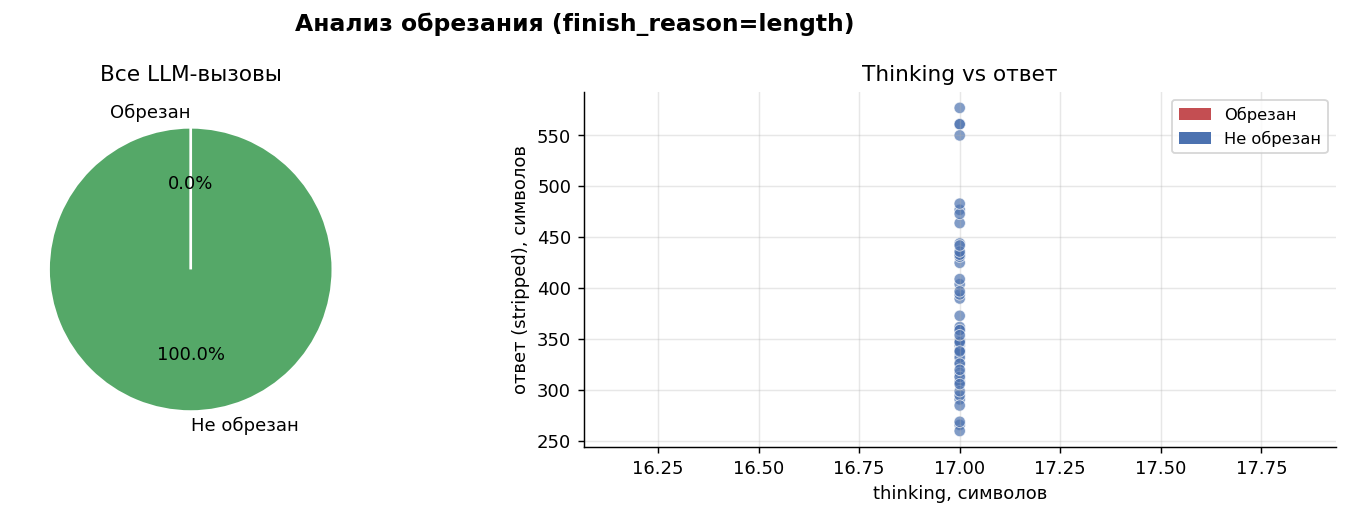

Обрезано всего: 0 из 52
  в т.ч. обрезан ответ (не thinking): 0
  в т.ч. обрезан thinking:            0


In [77]:
# ── Обрезание ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Анализ обрезания (finish_reason=length)', fontsize=13, fontweight='bold')

trunc_counts = calls['truncated'].value_counts()
axes[0].pie(
    [trunc_counts.get(False, 0), trunc_counts.get(True, 0)],
    labels=['Не обрезан', 'Обрезан'],
    autopct='%1.1f%%', colors=['#55A868', '#C44E52'],
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}, startangle=90,
)
axes[0].set_title('Все LLM-вызовы')

colors_sc = calls['truncated'].map({True: '#C44E52', False: '#4C72B0'})
axes[1].scatter(calls['think_chars'], calls['stripped_chars'],
                c=colors_sc, alpha=0.7, s=40, edgecolors='white', lw=0.5)
axes[1].set_xlabel('thinking, символов')
axes[1].set_ylabel('ответ (stripped), символов')
axes[1].set_title('Thinking vs ответ')
axes[1].legend(handles=[
    Patch(facecolor='#C44E52', label='Обрезан'),
    Patch(facecolor='#4C72B0', label='Не обрезан'),
], fontsize=9)

plt.tight_layout()
plt.show()

trunc_answer = calls[calls['truncated'] & (calls['stripped_chars'] > calls['think_chars'] * 0.5)]
print(f"Обрезано всего: {trunc_counts.get(True, 0)} из {len(calls)}")
print(f"  в т.ч. обрезан ответ (не thinking): {len(trunc_answer)}")
print(f"  в т.ч. обрезан thinking:            {trunc_counts.get(True, 0) - len(trunc_answer)}")

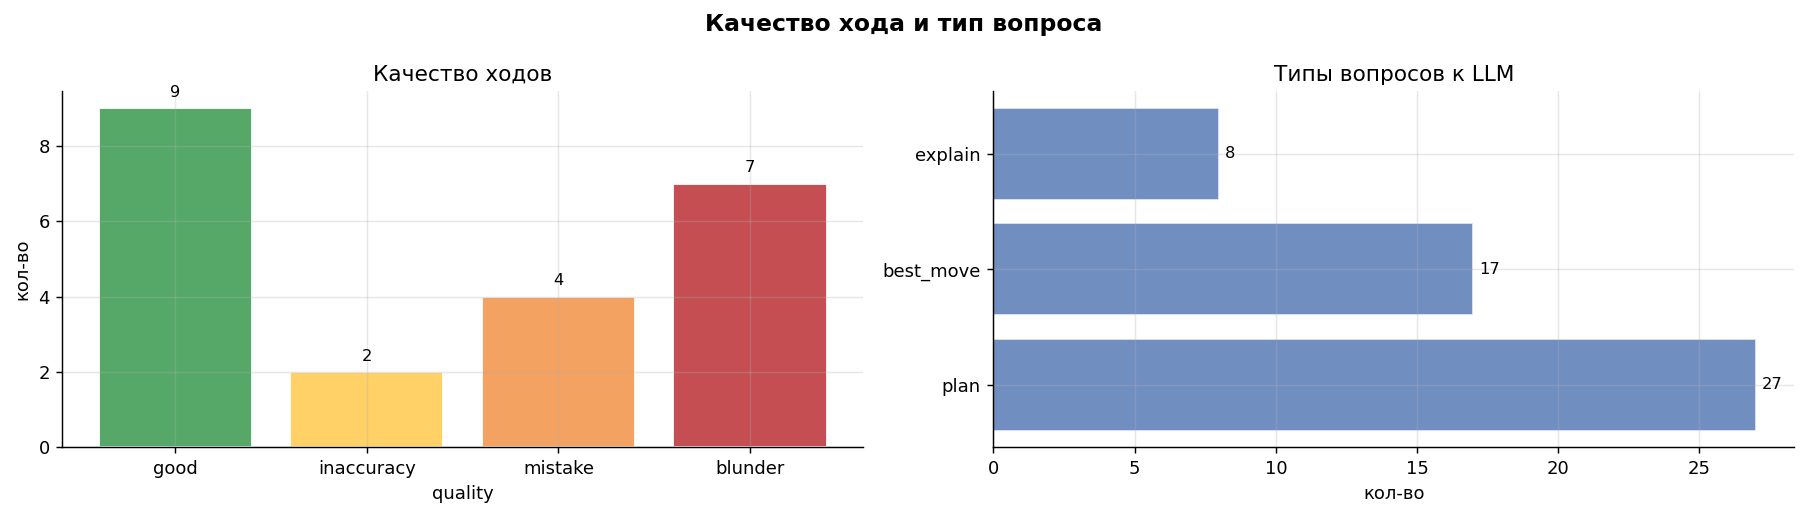

In [78]:
# ── Качество хода и тип вопроса ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('Качество хода и тип вопроса', fontsize=13, fontweight='bold')

QUALITY_ORDER  = ['book', 'good', 'inaccuracy', 'mistake', 'blunder']
QUALITY_COLORS = {'book':'#8dc6ff','good':'#55A868','inaccuracy':'#FFD166','mistake':'#f4a261','blunder':'#C44E52'}

q_counts = moves['quality'].value_counts()
q_order  = [q for q in QUALITY_ORDER if q in q_counts]
axes[0].bar(q_order, [q_counts[q] for q in q_order],
            color=[QUALITY_COLORS.get(q, '#aaa') for q in q_order], edgecolor='white')
axes[0].set_title('Качество ходов')
axes[0].set_xlabel('quality')
axes[0].set_ylabel('кол-во')
for i, q in enumerate(q_order):
    axes[0].text(i, q_counts[q] + 0.3, str(q_counts[q]), ha='center', fontsize=9)

qt = moves['question_type'].value_counts()
axes[1].barh(qt.index, qt.values, color='#4C72B0', alpha=0.8, edgecolor='white')
axes[1].set_title('Типы вопросов к LLM')
axes[1].set_xlabel('кол-во')
for i, v in enumerate(qt.values):
    axes[1].text(v + 0.2, i, str(v), va='center', fontsize=9)

plt.tight_layout()
plt.show()

## Корреляции

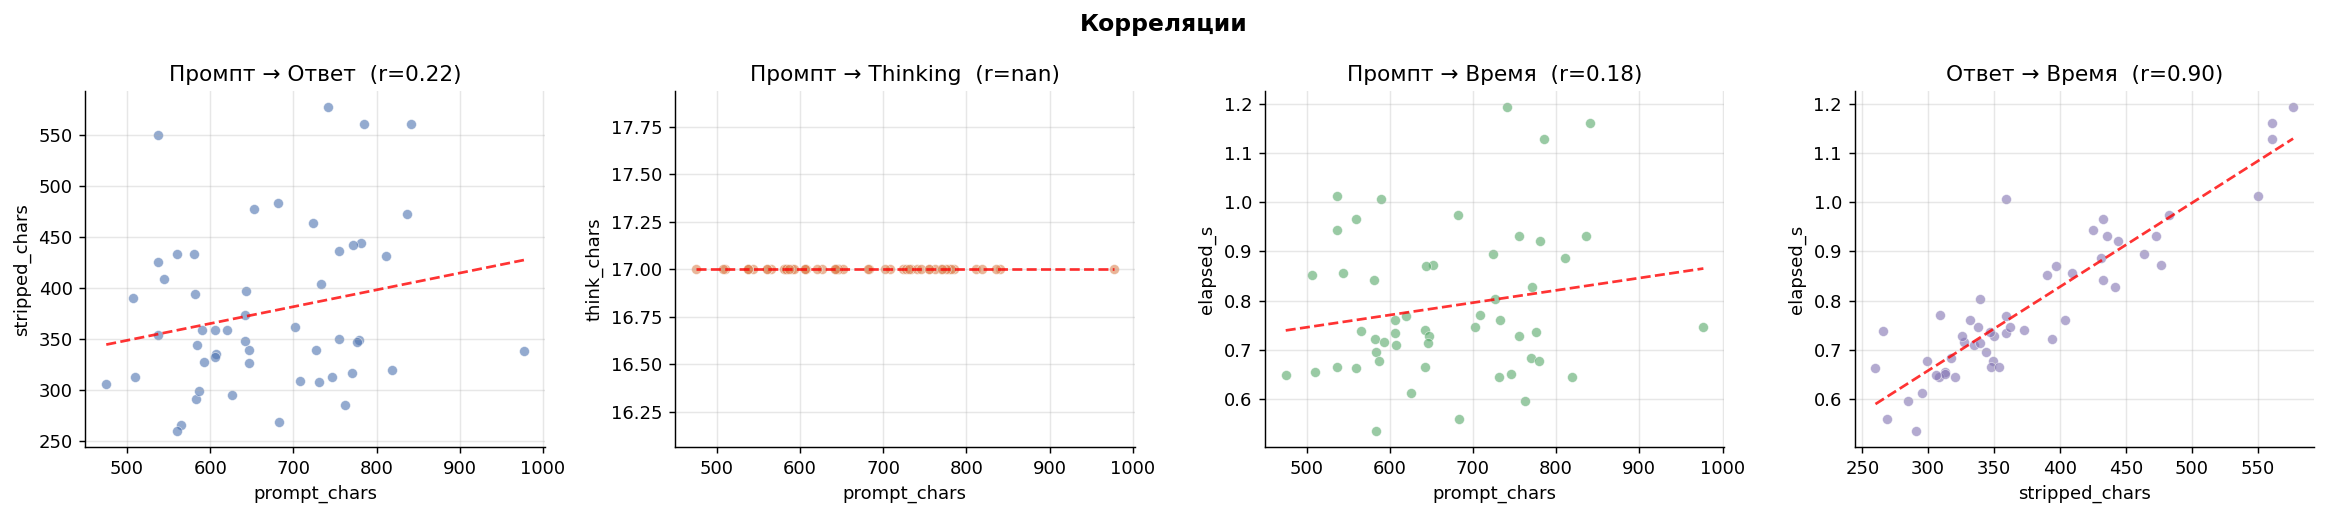

In [79]:
# ── Корреляции ────────────────────────────────────────────────────────────────
fc2 = first_calls[['move_index','prompt_chars','stripped_chars','think_chars','elapsed_s','truncated']].rename(columns={'move_index':'index'})
mfc2 = moves.merge(fc2, on='index', how='left')

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
fig.suptitle('Корреляции', fontsize=13, fontweight='bold')

pairs = [
    ('prompt_chars_x', 'stripped_chars', 'Промпт → Ответ',   '#4C72B0'),
    ('prompt_chars_x', 'think_chars',    'Промпт → Thinking','#DD8452'),
    ('prompt_chars_x', 'elapsed_s',      'Промпт → Время',   '#55A868'),
    ('stripped_chars', 'elapsed_s',      'Ответ → Время',     '#8172B2'),
]

for ax, (xcol, ycol, title, color) in zip(axes, pairs):
    data = mfc2[[xcol, ycol]].dropna()
    ax.scatter(data[xcol], data[ycol], color=color, alpha=0.6, s=30, edgecolors='white', lw=0.4)
    if len(data) > 2:
        z  = np.polyfit(data[xcol], data[ycol], 1)
        xs = np.linspace(data[xcol].min(), data[xcol].max(), 100)
        ax.plot(xs, np.poly1d(z)(xs), color='red', lw=1.5, linestyle='--', alpha=0.8)
        r = data[[xcol, ycol]].corr().iloc[0, 1]
        ax.set_title(f'{title}  (r={r:.2f})')
    else:
        ax.set_title(title)
    ax.set_xlabel(xcol.replace('_x', ''))
    ax.set_ylabel(ycol)

plt.tight_layout()
plt.show()

## Детальная таблица

In [80]:
# ── Детальная таблица по ходам ────────────────────────────────────────────────
detail = mfc[[
    'move_number', 'san', 'color', 'quality', 'question_type',
    'prompt_chars', 'stripped_chars', 'think_chars', 'total_elapsed_s',
    'n_calls', 'retried', 'truncated_raw', 'truncated_stripped', 'commentary_empty'
]].copy().rename(columns={
    'move_number':        '#',
    'san':                'Ход',
    'color':              'Цвет',
    'quality':            'Качество',
    'question_type':      'Тип вопроса',
    'prompt_chars':     'Промпт',
    'stripped_chars':     'Ответ',
    'think_chars':        'Thinking',
    'total_elapsed_s':    'Время, с',
    'n_calls':            'Вызовов',
    'retried':            'Ретрай',
    'truncated_raw':      'Обрез (raw)',
    'truncated_stripped': 'Обрез (ответ)',
    'commentary_empty':   'Пустой',
})

def _style(row):
    s = [''] * len(row)
    cols = list(row.index)
    if row.get('Пустой'):      s[cols.index('Пустой')] = 'background-color: #ffcccc'
    if row.get('Обрез (raw)'): s[cols.index('Обрез (raw)')] = 'background-color: #ffe0b2'
    if row.get('Ретрай'):      s[cols.index('Ретрай')] = 'background-color: #fff9c4'
    return s

detail.style\
    .apply(_style, axis=1)\
    .format({'Время, с': '{:.2f}', 'Промпт': '{:.0f}', 'Ответ': '{:.0f}', 'Thinking': '{:.0f}'})\
    .hide(axis='index')

#,Ход,Цвет,Качество,Тип вопроса,Промпт,Ответ,Thinking,"Время, с",Вызовов,Ретрай,Обрез (raw),Обрез (ответ),Пустой
1,d4,white,good,best_move,590,359,17,1.01,1,False,False,False,False
1,f5,black,good,plan,510,313,17,0.66,1,False,False,False,False
2,Nf3,white,best,plan,565,266,17,0.74,1,False,False,False,False
2,Nf6,black,best,plan,537,425,17,0.94,1,False,False,False,False
3,c3,white,excellent,plan,560,260,17,0.66,1,False,False,False,False
3,d5,black,best,plan,507,390,17,0.85,1,False,False,False,False
4,Bg5,white,excellent,plan,582,394,17,0.72,1,False,False,False,False
4,Nc6,black,excellent,plan,584,344,17,0.70,1,False,False,False,False
5,Qb3,white,excellent,plan,581,433,17,0.84,1,False,False,False,False
5,Ne4,black,excellent,plan,607,335,17,0.71,1,False,False,False,False


## Сравнение нескольких трейс-файлов

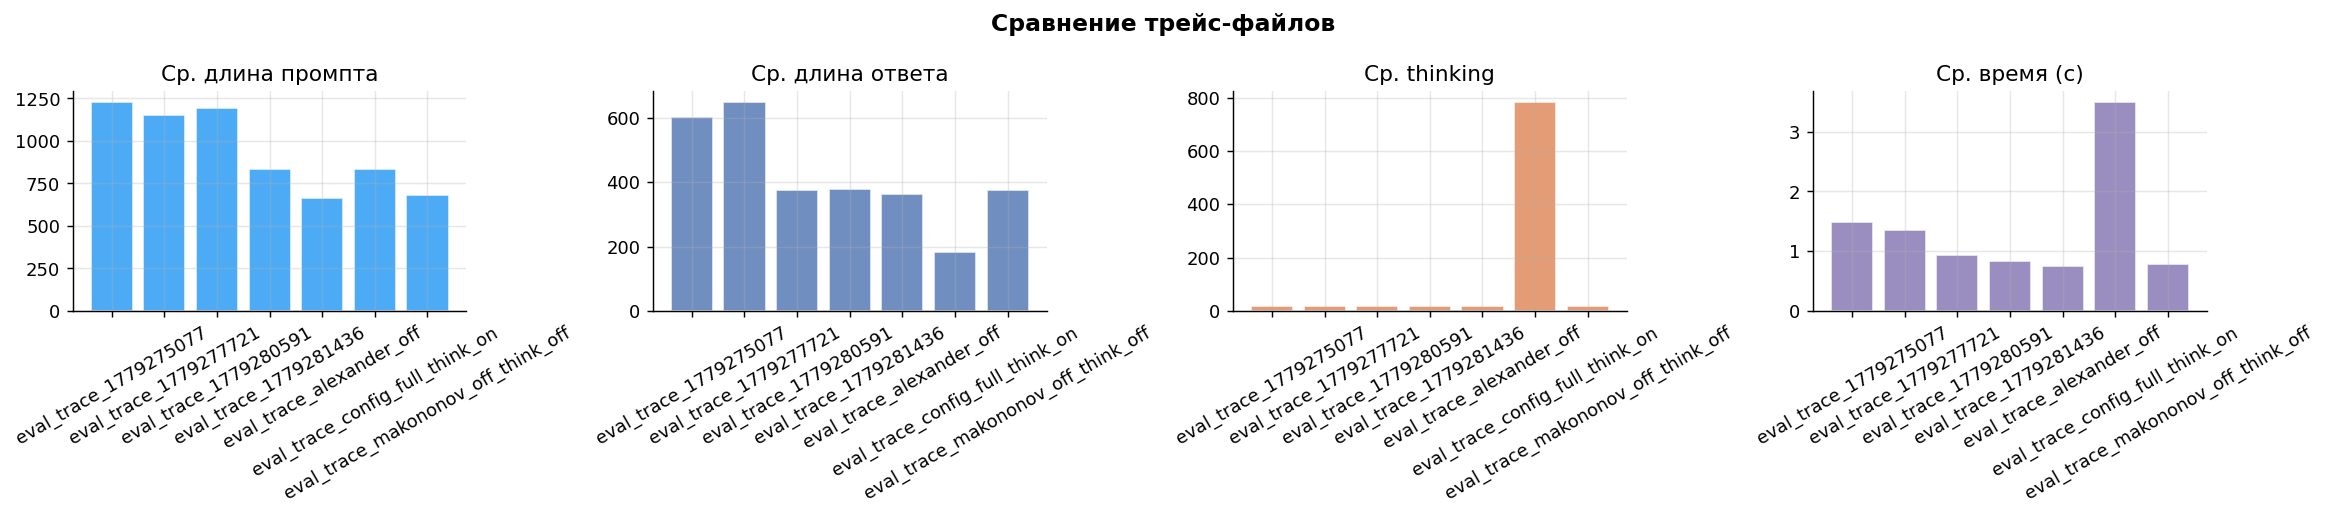

,файл,конфиг,max_tokens,ходов,вызовов,ср. промпт,ср. ответ,ср. thinking,обрезано,"ср. время, с",пустых
0,eval_trace_1779275077,full,350,127,127,1230.2,603.5,17.0,0,1.49,0
1,eval_trace_1779277721,full,350,52,52,1151.2,650.6,17.0,0,1.35,0
2,eval_trace_1779280591,full,350,52,52,1195.9,375.9,17.0,0,0.93,0
3,eval_trace_1779281436,full,350,52,52,835.5,380.2,17.0,0,0.84,0
4,eval_trace_alexander_off,"full+overrides={'include_mobility': False, 'in...",350,52,52,665.0,362.8,17.0,0,0.76,0
5,eval_trace_config_full_think_on,full,350,52,90,833.0,182.8,784.1,39,3.50,0
6,eval_trace_makononov_off_think_off,full+overrides={'include_makogonov': False},350,52,52,679.5,376.4,17.0,0,0.79,0


In [81]:
# ── Сравнение нескольких файлов ───────────────────────────────────────────────
if len(files) > 1:
    records = []
    for f in files:
        m, mv, cl, _ = parse_trace(f)
        fc_ = cl[cl['call_num'] == 0]
        records.append({
            'файл':             f.stem,
            'конфиг':           m['config'],
            'max_tokens':       m['max_tokens'],
            'ходов':            len(mv),
            'вызовов':          len(cl),
            'ср. промпт':       round(fc_['prompt_chars'].mean(), 1),
            'ср. ответ':        round(fc_['stripped_chars'].mean(), 1),
            'ср. thinking':     round(fc_['think_chars'].mean(), 1),
            'обрезано':         int(cl['truncated'].sum()),
            'ср. время, с':     round(fc_['elapsed_s'].mean(), 2),
            'пустых':           int(mv['commentary_empty'].sum()),
        })

    df_cmp = pd.DataFrame(records)

    fig, axes = plt.subplots(1, 4, figsize=(18, 4))
    fig.suptitle('Сравнение трейс-файлов', fontsize=13, fontweight='bold')

    for ax, (col, title, color) in zip(axes, [
        ('ср. промпт',   'Ср. длина промпта',  '#2196F3'),
        ('ср. ответ',    'Ср. длина ответа',   '#4C72B0'),
        ('ср. thinking', 'Ср. thinking',        '#DD8452'),
        ('ср. время, с', 'Ср. время (с)',        '#8172B2'),
    ]):
        ax.bar(df_cmp['файл'], df_cmp[col], color=color, alpha=0.8, edgecolor='white')
        ax.set_title(title)
        ax.tick_params(axis='x', rotation=30)

    plt.tight_layout()
    plt.show()
    display(df_cmp)
else:
    print('Только один трейс-файл — сравнение недоступно.')

## Флаги аномального детектора
Трейсинг включения/выключения каждого флага по ходам партии. Данные собираются в `eval_game.py` через поле `trace["anomaly"]`.

In [82]:
# ── Данные флагов аномального детектора ───────────────────────────────────────
data = json.loads(TRACE_FILE.read_text())  # raw JSON for anomaly trace
FLAG_COLS = [
    'show_score_table', 'show_game_phase', 'show_pawn_structure',
    'show_space', 'show_mobility', 'show_makogonov',
]
FLAG_LABELS = {
    'show_score_table':    'Score table',
    'show_game_phase':     'Game phase',
    'show_pawn_structure': 'Pawn structure',
    'show_space':          'Space',
    'show_mobility':       'Mobility',
    'show_makogonov':      'Makogonov',
}

anm_rows = []
for t in data['traces']:
    if t.get('san') is None or 'anomaly' not in t:
        continue
    a = t['anomaly']
    row = {
        'index':       t['index'],
        'san':         t.get('san'),
        'move_number': t.get('move_number'),
        'color':       t.get('color'),
        'eval_cp':     t.get('eval_cp'),
        'eval_loss_cp': t.get('eval_loss_cp'),
        'game_phase':  a.get('game_phase', ''),
        'prev_phase':  a.get('prev_game_phase', ''),
        'phase_transition': a.get('phase_transition_remark', False),
        'anomaly_summary': a.get('anomaly_summary', False),
        **{f: a.get(f, False) for f in FLAG_COLS},
        # raw numeric inputs for threshold sweep
        'eval_delta_cp':       a.get('eval_delta_cp'),
        'max_pawn_weaknesses': a.get('max_pawn_weaknesses'),
        'space_diff':          a.get('space_diff'),
        'score_mobility_abs':  a.get('score_mobility_abs'),
    }
    for k, v in a.get('thresholds', {}).items():
        row[f'thr_{k}'] = v
    anm_rows.append(row)

anm = pd.DataFrame(anm_rows)
print(f'Позиций с данными детектора: {len(anm)}')
if anm.empty:
    print('Нет данных — запустите eval_game.py с новой версией.')
else:
    print()
    print(f'  {"Флаг":<24}  {"Включён":>8}  {"Выключен":>9}  {"% вкл.":>7}')
    print('  ' + '-' * 55)
    for f in FLAG_COLS:
        on  = int(anm[f].sum())
        off = len(anm) - on
        pct = on / len(anm) * 100
        print(f'  {FLAG_LABELS[f]:<24}  {on:>8}  {off:>9}  {pct:>6.1f}%')
    pt = int(anm['phase_transition'].sum())
    print(f'  {"Phase transition":<24}  {pt:>8}  {len(anm)-pt:>9}  {pt/len(anm)*100:>6.1f}%')
    print(f'  {"Structural alerts":<24}  {int(anm["anomaly_summary"].sum()):>8}')


Позиций с данными детектора: 52

  Флаг                       Включён   Выключен   % вкл.
  -------------------------------------------------------
  Score table                     12         40    23.1%
  Game phase                      30         22    57.7%
  Pawn structure                   0         52     0.0%
  Space                            8         44    15.4%
  Mobility                        17         35    32.7%
  Makogonov                       23         29    44.2%
  Phase transition                 2         50     3.8%
  Structural alerts               18


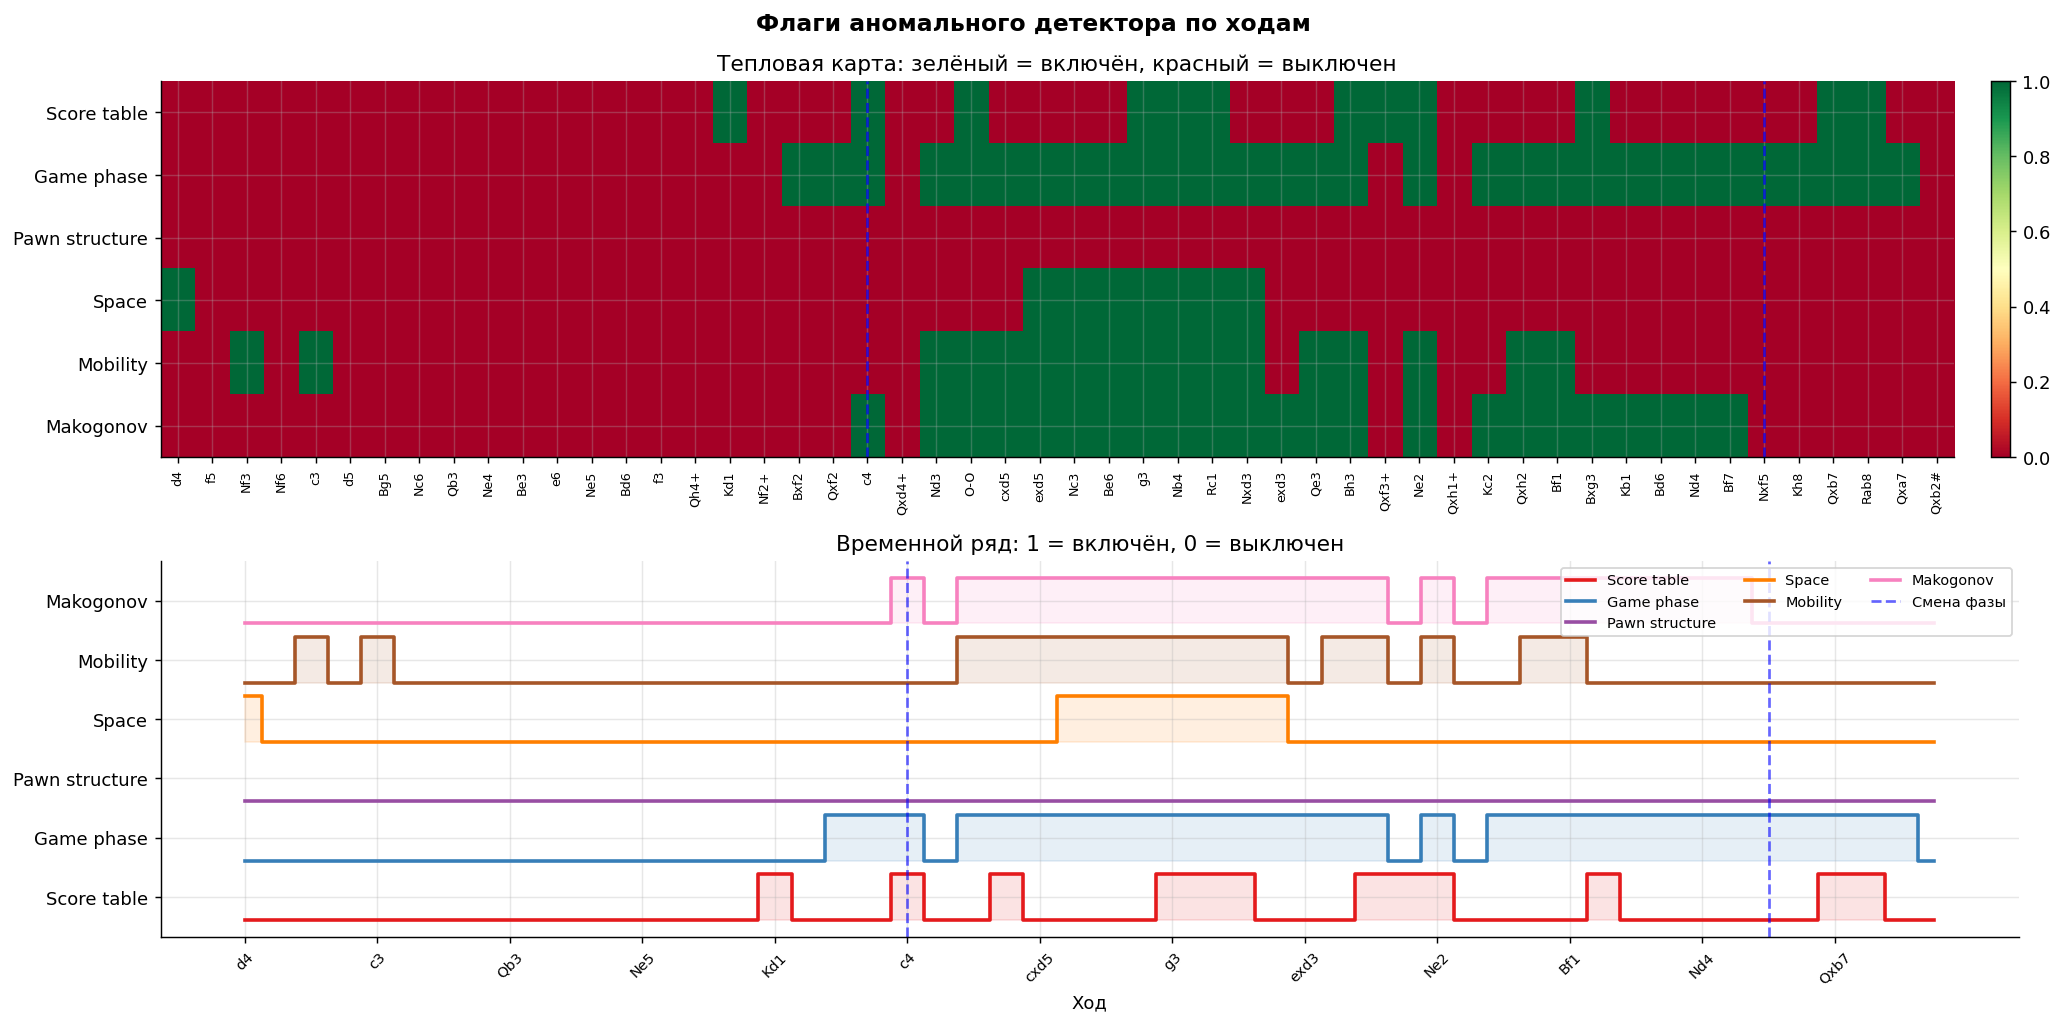


Фазы партии:
  Ход d4 (#1): Opening
  Ход Qh4+ (#16): 
  Ход Bxf2 (#19): Transition to middlegame
  Ход c4 (#21): Middlegame
  Ход Nxf5 (#47): Transition to endgame


In [83]:
# ── Временной график и тепловая карта флагов ──────────────────────────────────
if not anm.empty:
    fig, axes = plt.subplots(2, 1, figsize=(16, 8))
    fig.suptitle('Флаги аномального детектора по ходам', fontsize=13, fontweight='bold')

    # ── Тепловая карта ──────────────────────────────────────────────────────
    ax = axes[0]
    hm_data = anm.set_index('index')[FLAG_COLS].T.astype(int)
    im = ax.imshow(hm_data.values, aspect='auto', cmap='RdYlGn',
                   vmin=0, vmax=1, interpolation='none')
    ax.set_yticks(range(len(FLAG_COLS)))
    ax.set_yticklabels([FLAG_LABELS[f] for f in FLAG_COLS])
    ax.set_xticks(range(len(anm)))
    ax.set_xticklabels(anm['san'].tolist(), rotation=90, fontsize=7)
    ax.set_title('Тепловая карта: зелёный = включён, красный = выключен')
    plt.colorbar(im, ax=ax, fraction=0.015, pad=0.02)

    # Отметить смены фазы
    for _, row in anm.iterrows():
        if row['phase_transition']:
            xi = anm[anm['index'] == row['index']].index[0]
            ax.axvline(xi, color='blue', lw=1.5, linestyle='--', alpha=0.7)

    # ── Step-plot по флагам ─────────────────────────────────────────────────
    ax2 = axes[1]
    colors_f = plt.cm.Set1(np.linspace(0, 0.85, len(FLAG_COLS)))
    x_pos = list(range(len(anm)))
    for i, (f, c) in enumerate(zip(FLAG_COLS, colors_f)):
        y = anm[f].astype(int).values + i * 1.3
        ax2.step(x_pos, y, where='mid', color=c, lw=2, label=FLAG_LABELS[f])
        ax2.fill_between(x_pos, i * 1.3, y, step='mid', alpha=0.12, color=c)
    ax2.set_yticks([i * 1.3 + 0.5 for i in range(len(FLAG_COLS))])
    ax2.set_yticklabels([FLAG_LABELS[f] for f in FLAG_COLS])
    ax2.set_xticks(x_pos[::4])
    ax2.set_xticklabels(anm['san'].tolist()[::4], rotation=45, fontsize=8)
    ax2.set_title('Временной ряд: 1 = включён, 0 = выключен')
    ax2.set_xlabel('Ход')

    # Смены фазы — вертикальные линии
    for xi, row in enumerate(anm.itertuples()):
        if row.phase_transition:
            ax2.axvline(xi, color='blue', lw=1.5, linestyle='--', alpha=0.6,
                        label='Смена фазы' if xi == anm[anm['phase_transition']].index[0] else '')

    ax2.legend(fontsize=8, loc='upper right', ncol=3)
    plt.tight_layout()
    plt.show()

    # Фазы по ходам
    print('\nФазы партии:')
    for _, row in anm.drop_duplicates('game_phase', keep='first').iterrows():
        print(f'  Ход {row["san"]} (#{row["index"]}): {row["game_phase"]}')


## Анализ чувствительности порогов
Для каждого флага с числовым порогом: какой % ходов даёт включение при каждом значении порога.
Красная вертикальная линия — текущее значение из конфига.

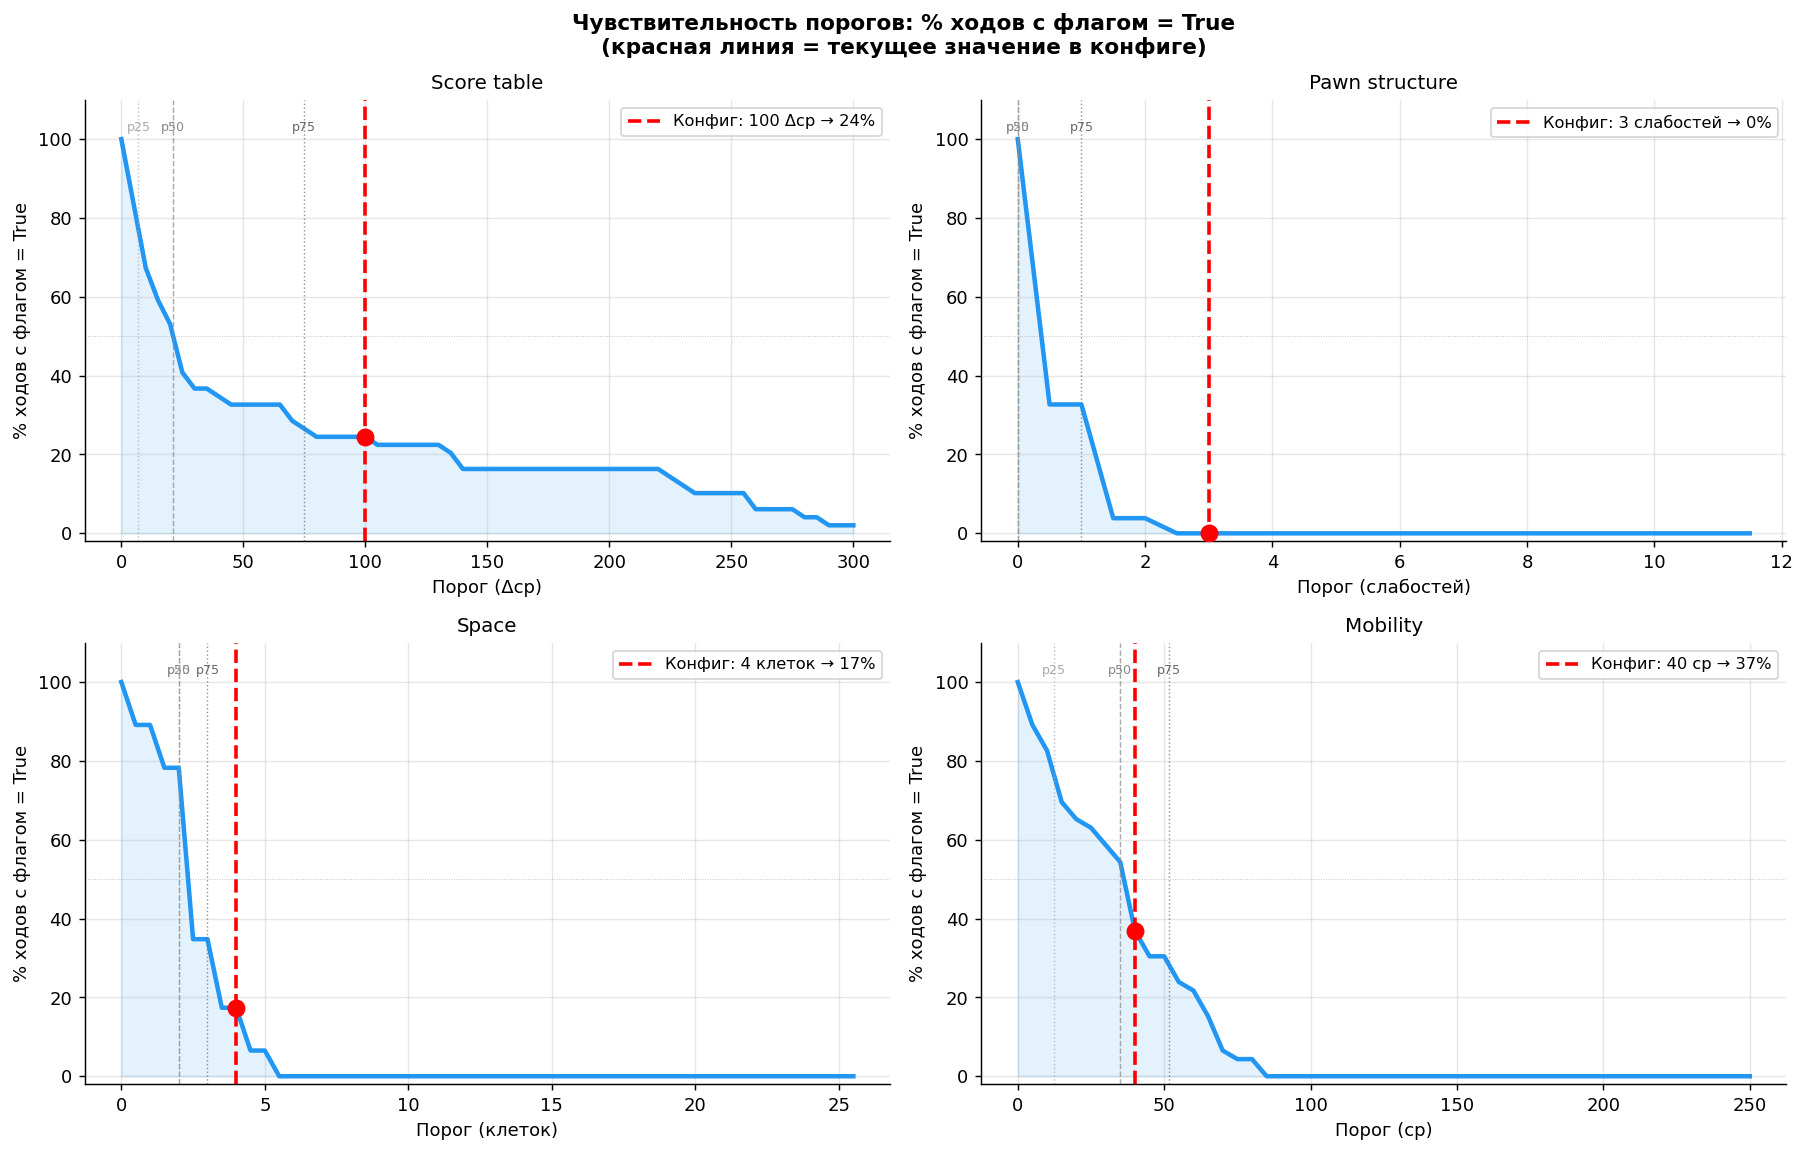


  Флаг                       Порог       Ед.    Значение   Пожаров
  -----------------------------------------------------------------
  Score table             score_jump_threshold_cp       Δcp         100   12/49 (24%)
  Pawn structure          pawn_weakness_threshold  слабостей           3    0/52 (0%)
  Space                   space_imbalance_threshold    клеток           4    8/46 (17%)
  Mobility                mobility_score_threshold        cp          40   17/46 (37%)


In [84]:
# ── Анализ чувствительности порогов ──────────────────────────────────────────
# Для каждого числового порога: % ходов с flag=True в зависимости от значения порога
if not anm.empty:
    SWEEPS = [
        ('show_score_table',    'eval_delta_cp',       'score_jump_threshold_cp',
         np.arange(0, 301, 5),  'Δcp',         'Score table'),
        ('show_pawn_structure', 'max_pawn_weaknesses', 'pawn_weakness_threshold',
         np.arange(0, 12, 0.5), 'слабостей',   'Pawn structure'),
        ('show_space',          'space_diff',          'space_imbalance_threshold',
         np.arange(0, 26, 0.5), 'клеток',      'Space'),
        ('show_mobility',       'score_mobility_abs',  'mobility_score_threshold',
         np.arange(0, 251, 5),  'cp',           'Mobility'),
    ]

    fig, axes = plt.subplots(2, 2, figsize=(14, 9))
    fig.suptitle(
        'Чувствительность порогов: % ходов с флагом = True\n'
        '(красная линия = текущее значение в конфиге)',
        fontsize=12, fontweight='bold'
    )
    axes = axes.flatten()

    for ax, (flag, input_col, thr_col, thresholds, unit, label) in zip(axes, SWEEPS):
        values = anm[input_col].dropna()
        if values.empty:
            ax.text(0.5, 0.5, 'Нет данных', transform=ax.transAxes, ha='center', va='center')
            ax.set_title(label)
            continue

        pcts = [(values >= thr).mean() * 100 for thr in thresholds]

        # Основная кривая
        ax.plot(thresholds, pcts, color='#2196F3', lw=2.5)
        ax.fill_between(thresholds, pcts, alpha=0.12, color='#2196F3')

        # Текущий порог из конфига
        thr_key = f'thr_{thr_col}'
        current_thr = anm[thr_key].iloc[0] if thr_key in anm.columns else None
        if current_thr is not None:
            current_pct = (values >= current_thr).mean() * 100
            ax.axvline(current_thr, color='red', lw=2, linestyle='--',
                       label=f'Конфиг: {current_thr} {unit} → {current_pct:.0f}%')
            ax.scatter([current_thr], [current_pct], color='red', s=80, zorder=5)

        # Квантили входных значений
        for p, col, ls in [(25, '#aaa', ':'), (50, '#888', '--'), (75, '#666', ':')]:
            pv = float(np.percentile(values, p))
            ax.axvline(pv, color=col, lw=0.8, linestyle=ls, alpha=0.7)
            ax.text(pv, 102, f'p{p}', fontsize=7, color=col, ha='center')

        ax.set_title(label, fontsize=11)
        ax.set_xlabel(f'Порог ({unit})')
        ax.set_ylabel('% ходов с флагом = True')
        ax.set_ylim(-2, 110)
        ax.axhline(50, color='gray', lw=0.5, linestyle=':', alpha=0.5)
        if current_thr is not None:
            ax.legend(fontsize=9)

    plt.tight_layout()
    plt.show()

    # Таблица текущих значений
    print(f'\n  {"Флаг":<22}  {"Порог":>8}  {"Ед.":>8}  {"Значение":>10}  {"Пожаров":>8}')
    print('  ' + '-' * 65)
    for flag, input_col, thr_col, _, unit, label in SWEEPS:
        if input_col not in anm.columns:
            continue
        values = anm[input_col].dropna()
        thr_key = f'thr_{thr_col}'
        current_thr = anm[thr_key].iloc[0] if thr_key in anm.columns else None
        if current_thr is not None and len(values) > 0:
            fires = int((values >= current_thr).sum())
            total = len(values)
            print(f'  {label:<22}  {thr_col:>8}  {unit:>8}  {current_thr:>10}  '
                  f'{fires:>3}/{total} ({fires/total*100:.0f}%)')


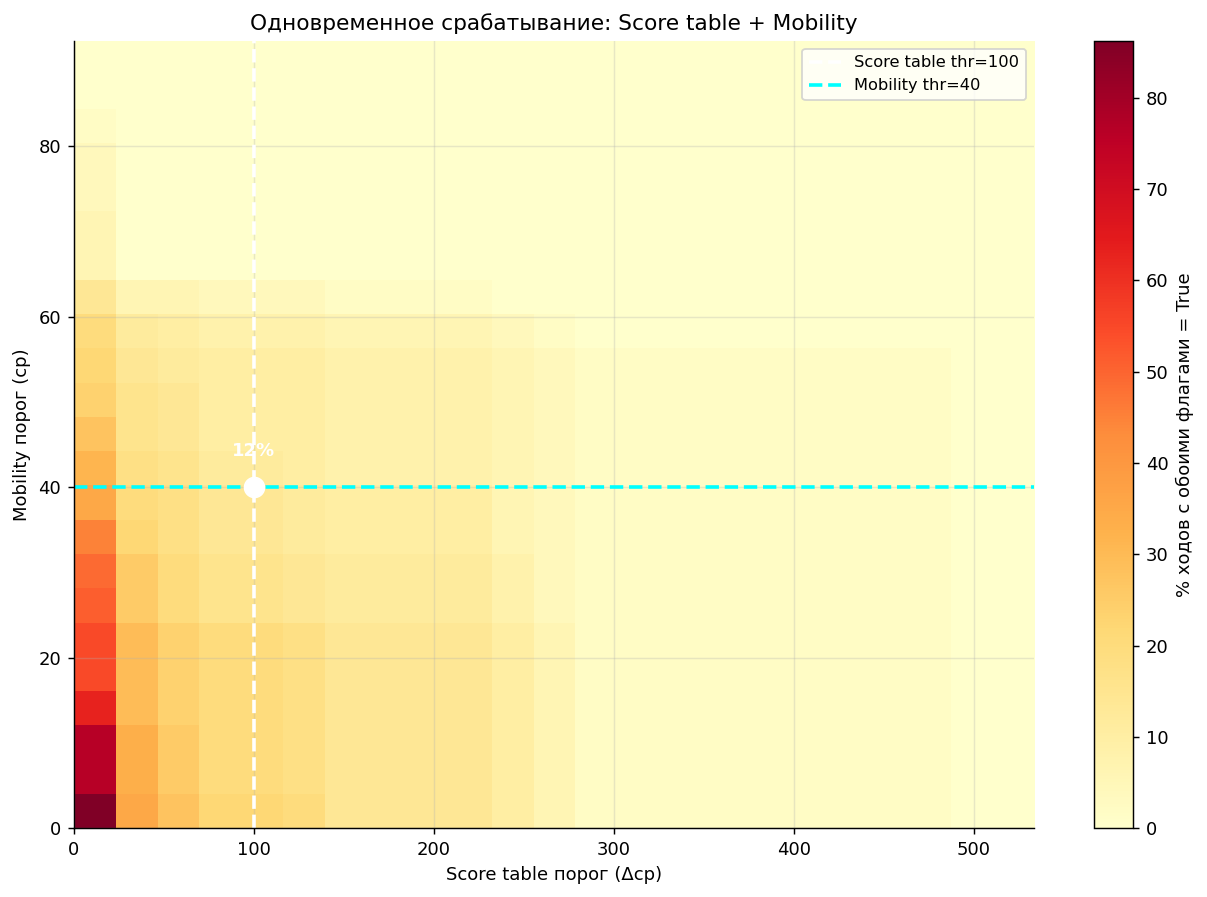

In [85]:
# ── Сводная матрица порогов ───────────────────────────────────────────────────
# Показывает % ходов с включённым флагом для каждой комбинации порогов.
# Удобно для выбора двух порогов одновременно.
if not anm.empty:
    PAIRS = [
        ('eval_delta_cp',       'score_jump_threshold_cp',   'Δcp',     'Score table'),
        ('score_mobility_abs',  'mobility_score_threshold',  'cp',      'Mobility'),
    ]
    # Выбираем два флага с числовыми данными для 2D-матрицы
    pair_data = [(c, t, u, l) for c, t, u, l in PAIRS if anm[c].notna().any()]

    if len(pair_data) >= 2:
        (c1, t1, u1, l1), (c2, t2, u2, l2) = pair_data[:2]
        v1 = anm[c1].dropna()
        v2 = anm[c2].dropna()
        grid1 = np.arange(0, max(v1) * 1.1 + 1, max(v1) / 20)
        grid2 = np.arange(0, max(v2) * 1.1 + 1, max(v2) / 20)

        matrix = np.zeros((len(grid2), len(grid1)))
        for i, thr2 in enumerate(grid2):
            for j, thr1 in enumerate(grid1):
                # % where BOTH flags fire simultaneously
                both = ((v1 >= thr1) & (v2 >= thr2)).mean() * 100
                matrix[i, j] = both

        fig, ax = plt.subplots(figsize=(10, 7))
        im = ax.imshow(matrix, aspect='auto', origin='lower', cmap='YlOrRd',
                       extent=[grid1[0], grid1[-1], grid2[0], grid2[-1]])
        plt.colorbar(im, ax=ax, label='% ходов с обоими флагами = True')

        # Текущие пороги
        curr1 = anm[f'thr_{t1}'].iloc[0] if f'thr_{t1}' in anm.columns else None
        curr2 = anm[f'thr_{t2}'].iloc[0] if f'thr_{t2}' in anm.columns else None
        if curr1:
            ax.axvline(curr1, color='white', lw=2, linestyle='--', label=f'{l1} thr={curr1}')
        if curr2:
            ax.axhline(curr2, color='cyan',  lw=2, linestyle='--', label=f'{l2} thr={curr2}')
        if curr1 and curr2:
            both_val = ((v1 >= curr1) & (v2 >= curr2)).mean() * 100
            ax.scatter([curr1], [curr2], color='white', s=120, zorder=5)
            ax.text(curr1, curr2 + max(grid2) * 0.04,
                    f'{both_val:.0f}%', color='white', fontsize=10,
                    ha='center', fontweight='bold')

        ax.set_xlabel(f'{l1} порог ({u1})')
        ax.set_ylabel(f'{l2} порог ({u2})')
        ax.set_title(f'Одновременное срабатывание: {l1} + {l2}', fontsize=12)
        ax.legend(fontsize=9)
        plt.tight_layout()
        plt.show()
    else:
        print('Недостаточно числовых данных для матрицы.')
